In [ ]:
import pandas as pd
import numpy as np
import arviz as az
from jax import numpy as jnp
from jax.random import PRNGKey
import numpyro
from numpyro import distributions as dist
from numpyro import infer

pd.options.plotting.backend = "plotly"

from summer3.graph import defer, CompartmentValues, Parameter
from summer3.epi import CompartmentalEpiModel, CompartmentMap, CompartmentalModelODE, \
    CategoryData, TransitionFlow, InfectionProcess, Stratification, \
    strat_data_from_pandas, build_istate, dti_to_epoch

from tb_macro.constants import LATENT_COMPS, ACTIVE_COMPS, OTHER_COMPS, REINFECT_COMPS

In [2]:
compartments = LATENT_COMPS + ACTIVE_COMPS + OTHER_COMPS
disease_state = Stratification("disease_state", compartments)
humans = CompartmentMap.new(disease_state)

In [3]:
age_strat = humans.stratify(Stratification("age", ["child", "adult"]))
age_cats = age_strat.categories()

In [4]:
iprocess = defer(InfectionProcess)(age_cats, age_cats, disease_state["clin"])

In [5]:
infect_strat = Stratification("infectious", ["non_infectious", "infectious"])
humans.stratify(infect_strat, (disease_state, ["subclin", "clin"]))

Stratification: infectious

In [6]:
times = pd.Index(np.arange(1800.0, 2000.0, 1.0))
epi_model = CompartmentalEpiModel(humans, times)
recovery = TransitionFlow(
    "recovery",
    disease_state["clin"],
    disease_state["recovered"],
    1.0 / Parameter("recovery_time", 10.0),
)
epi_model.add_flow(recovery)

# First infection
contact_rate = Parameter("contact_rate", 0.2)
foi = defer(InfectionProcess.process)(iprocess, CompartmentValues, contact_rate)
infection = TransitionFlow("infection", disease_state["mtb_naive"], disease_state["clin"], foi)
epi_model.add_flow(infection)

# Reinfection
reinfect_contact_rate = contact_rate * Parameter("rel_sus_cleared", 1.0)
reinfect_foi = defer(InfectionProcess.process)(iprocess, CompartmentValues, reinfect_contact_rate)
for comp in REINFECT_COMPS:
    reinfect = TransitionFlow(f"reinfect_{comp}", disease_state[comp], disease_state["clin"], reinfect_foi)
    epi_model.add_flow(reinfect)

# Other structural flows
contain = TransitionFlow(
    "containment", 
    disease_state["incipient"], 
    disease_state["contained"], 
    Parameter("contain", 0.0),
)
epi_model.add_flow(contain)

clearance = TransitionFlow(
    "clearance",
    disease_state["contained"],
    disease_state["cleared"],
    Parameter("clearance_rate", 0.0),
)
epi_model.add_flow(clearance)

breakdown = TransitionFlow(
    "breakdown",
    disease_state["contained"],
    disease_state["incipient"],
    Parameter("breakdown_rate", 0.0),
)
epi_model.add_flow(breakdown)

progression = TransitionFlow(
    "progression",
    disease_state["incipient"],
    disease_state["subclin"],
    Parameter("progression", 0.0),
)
epi_model.add_flow(progression)

In [7]:
pop_data = pd.Series(index=["child", "adult"], data=np.array([1000.0, 1500.0]))
base_pops = strat_data_from_pandas(pop_data, age_strat)
init_splits = [0.0] * len(compartments)
init_splits[compartments.index("mtb_naive")] = 0.9
init_splits[compartments.index("clin")] = 0.1
pop_splits = [CategoryData(disease_state.categories(), jnp.array((init_splits)))]

epi_model.set_initial_population(base_pops, pop_splits)

In [8]:
def get_runner(epi_model, params: dict[str, float]):
    istate = build_istate(epi_model.cmap, epi_model.base_pops, epi_model.pop_splits)
    cmodel = CompartmentalModelODE(epi_model.cmap, epi_model.flows)
    runner = cmodel.get_runner(
        len(epi_model.times), dti_to_epoch(epi_model.times), True
    )
    return runner, istate

In [9]:
base_params = {
    "contact_rate": 0.2, 
    "recovery_time": 20.0, 
    "rel_sus_cleared": 1.0, 
    "contain": 0.0,
    "clearance_rate": 0.0,
    "breakdown_rate": 0.0,
    "progression": 0.0,
}
runner, istate = get_runner(epi_model, base_params)
results = epi_model.run(base_params)

Gather
Scatter
Scatter
Scatter
Scatter
Scatter
Gather
Scatter
Scatter
Scatter
Scatter
Scatter


In [10]:
inf_target = (
    results["flows"]["infection"]
    .sum(to_dims="time")
    .to_pandas_df()
    .rolling(7)
    .sum()[7:60:7]
)["data"]
inf_target_fuzzy = inf_target * np.exp(
    np.random.normal(scale=0.01, size=len(inf_target))
)
inf_target_fuzzy.plot()

In [11]:
def get_derived_results(params):
    results = epi_model.run(params)  # runner.run(istate.data, params)
    inf_flow = results["flows"]["infection"]
    weekly_target = (
        inf_flow.sum(to_dims="time").rolling(7, jnp.sum).query(time=inf_target.index)
    )
    return weekly_target

In [12]:
priors = {
    "contact_rate": dist.Uniform(0.001, 0.5),
    "recovery_time": dist.Uniform(10.0, 50.0),
}

In [13]:
def model():
    params = base_params | {k: numpyro.sample(k, v) for k, v in priors.items()}
    weekly_modelled = get_derived_results(params)

    ll = dist.Poisson(inf_target_fuzzy.to_numpy()).log_prob(weekly_modelled.data)
    numpyro.factor("ll", ll)

In [14]:
kernel = infer.NUTS(model)
mcmc = infer.MCMC(kernel, num_warmup=200, num_samples=200, num_chains=4)
k = PRNGKey(0)
mcmc.run(k)

Gather
Scatter
Scatter
Scatter
Scatter
Scatter
Gather
Scatter
Scatter
Scatter
Scatter
Scatter


  0%|          | 0/400 [00:00<?, ?it/s]

  0%|          | 0/400 [00:00<?, ?it/s]

  0%|          | 0/400 [00:00<?, ?it/s]

  0%|          | 0/400 [00:00<?, ?it/s]

Gather
Scatter
Scatter
Scatter
Scatter
Scatter


W0320 14:23:11.598776 1974222 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


In [15]:
idata = az.from_numpyro(mcmc)

KeyboardInterrupt: 

In [ ]:
az.summary(idata)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
contact_rate,0.194,0.006,0.185,0.204,0.001,0.00,151.0,273.0,1.01
recovery_time,31.668,10.006,16.230,49.474,0.845,0.36,128.0,204.0,1.01


array([<Axes: title={'center': 'contact_rate'}>,
       <Axes: title={'center': 'recovery_time'}>], dtype=object)

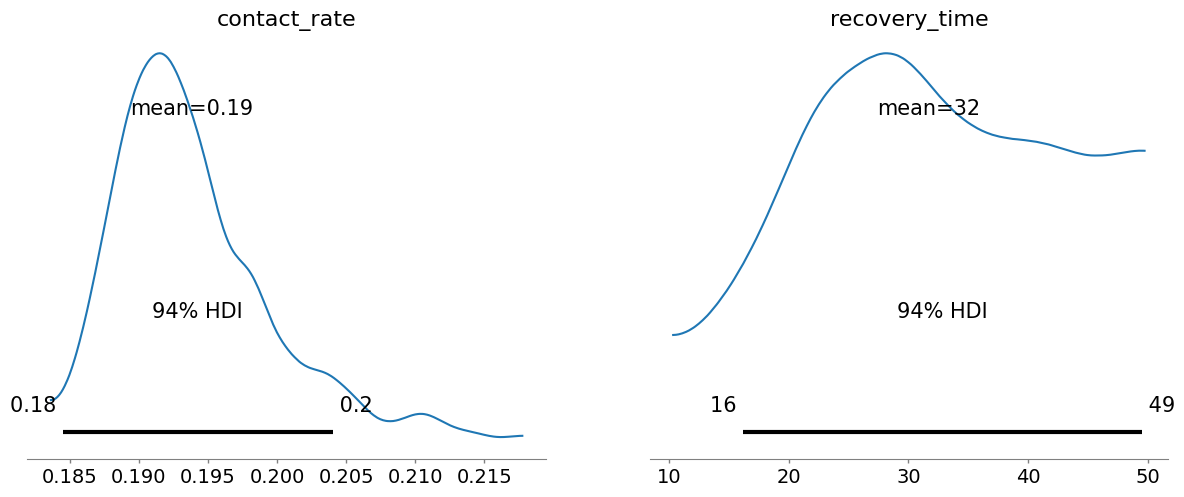

In [ ]:
az.plot_posterior(idata)

array([[<Axes: title={'center': 'contact_rate'}>,
        <Axes: title={'center': 'contact_rate'}>],
       [<Axes: title={'center': 'recovery_time'}>,
        <Axes: title={'center': 'recovery_time'}>]], dtype=object)

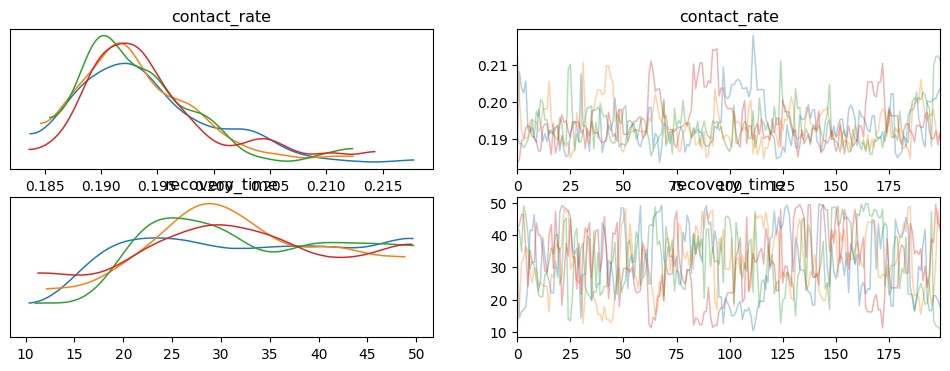

In [ ]:
az.plot_trace(idata, compact=False)